In [1]:

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from typing import Dict, List, Tuple
import time

# Load the existing N=10,000 data
with open('omega_decomposition_peaks_N10000.pkl', 'rb') as f:
 omega_data_N10k = pickle.load(f)

# Check the structure and extract r values for zeta and liouville
print("Available functions in N=10,000 data:", omega_data_N10k.keys())
print("\nNumber of peaks for each function:")
for func in omega_data_N10k.keys():
 print(f" {func}: {len(omega_data_N10k[func])}")

# Examine first peak structure for zeta
print("\nStructure of first zeta peak:")
print(omega_data_N10k['zeta'][0].keys())

# Extract r values and peak heights for N=10,000
zeta_peaks_N10k = omega_data_N10k['zeta']
liouville_peaks_N10k = omega_data_N10k['liouville']

print(f"\nN=10,000 Zeta - First 5 peaks:")
for i in range(5):
 print(f" Peak {i+1}: t={zeta_peaks_N10k[i]['t']:.2f}, height={zeta_peaks_N10k[i]['peak_height']:.4f}, r={zeta_peaks_N10k[i]['r']:.4f}")

print(f"\nN=10,000 Liouville - First 5 peaks:")
for i in range(5):
 print(f" Peak {i+1}: t={liouville_peaks_N10k[i]['t']:.2f}, height={liouville_peaks_N10k[i]['peak_height']:.4f}, r={liouville_peaks_N10k[i]['r']:.4f}")


Available functions in N=10,000 data: dict_keys(['zeta', 'L_DH', 'liouville'])

Number of peaks for each function:
 zeta: 200
 L_DH: 200
 liouville: 200

Structure of first zeta peak:
dict_keys(['t', 'peak_height', 'S_k', 'r'])

N=10,000 Zeta - First 5 peaks:
 Peak 1: t=19834.92, height=3.0552, r=-0.0084
 Peak 2: t=13016.51, height=3.0557, r=-0.2587
 Peak 3: t=18454.23, height=3.0693, r=1.1457
 Peak 4: t=11955.98, height=3.0980, r=-0.0842
 Peak 5: t=10300.15, height=3.1366, r=0.6379

N=10,000 Liouville - First 5 peaks:
 Peak 1: t=19834.92, height=3.0552, r=-0.9425
 Peak 2: t=13016.51, height=3.0557, r=-0.9617
 Peak 3: t=18454.23, height=3.0693, r=-0.7964
 Peak 4: t=11955.98, height=3.0980, r=-0.9864
 Peak 5: t=10300.15, height=3.1366, r=-0.8846


In [2]:

# Define the analysis plan
print("=" * 80)
print("ANALYSIS PLAN")
print("=" * 80)
print("""
Step 1: Extract and organize N=10,000 data
 - Extract r values and peak heights for zeta and liouville functions
 - Bin peaks into quartiles by height (Q1-Q4)
 - Compute mean r for each quartile

Step 2: Generate computations for N=10^5
 - Set T = N = 10^5, evaluate t ∈ [10^5, 2*10^5]
 - Compute Dirichlet polynomials for zeta and Liouville functions
 - Find top 200 peaks
 - Compute ω-class decomposition and r at each peak
 - Bin by quartile and compute mean r

Step 3: Generate computations for N=10^6
 - Set T = N = 10^6, evaluate t ∈ [10^6, 2*10^6]
 - Repeat same analysis as N=10^5

Step 4: Combine results and create visualizations
 - Create tables of mean r per quartile for each N and function
 - Plot mean r vs N on log scale for each quartile
 - Generate final summary figure

Computational Considerations:
 - N=10^5: ~100,000 terms per sum, 2000 t-points → manageable
 - N=10^6: ~1,000,000 terms per sum, 2000 t-points → computationally intensive
 - Will use Kahan summation for numerical stability
 - Will pre-compute necessary arrays (primes, ω(n), Ω(n))
 - Runtime limit: 5400 seconds
""")
print("=" * 80)


ANALYSIS PLAN

Step 1: Extract and organize N=10,000 data
 - Extract r values and peak heights for zeta and liouville functions
 - Bin peaks into quartiles by height (Q1-Q4)
 - Compute mean r for each quartile

Step 2: Generate computations for N=10^5
 - Set T = N = 10^5, evaluate t ∈ [10^5, 2*10^5]
 - Compute Dirichlet polynomials for zeta and Liouville functions
 - Find top 200 peaks
 - Compute ω-class decomposition and r at each peak
 - Bin by quartile and compute mean r

Step 3: Generate computations for N=10^6
 - Set T = N = 10^6, evaluate t ∈ [10^6, 2*10^6]
 - Repeat same analysis as N=10^5

Step 4: Combine results and create visualizations
 - Create tables of mean r per quartile for each N and function
 - Plot mean r vs N on log scale for each quartile
 - Generate final summary figure

Computational Considerations:
 - N=10^5: ~100,000 terms per sum, 2000 t-points → manageable
 - N=10^6: ~1,000,000 terms per sum, 2000 t-points → computationally intensive
 - Will use Kahan summati

In [3]:

# Step 1: Process N=10,000 data and create quartile analysis function

def bin_peaks_by_quartile(peak_data: List[Dict]) -> Dict[str, Dict]:
 """
 Bin peaks into quartiles by height and compute statistics.
 
 Parameters:
 -----------
 peak_data : List[Dict]
 List of peak dictionaries with 'peak_height' and 'r' keys
 
 Returns:
 --------
 Dict with quartile statistics
 """
 # Extract heights and r values
 heights = np.array([p['peak_height'] for p in peak_data])
 r_values = np.array([p['r'] for p in peak_data])
 
 # Compute quartile boundaries
 q1_thresh = np.percentile(heights, 25)
 q2_thresh = np.percentile(heights, 50)
 q3_thresh = np.percentile(heights, 75)
 
 # Bin peaks
 q1_mask = heights <= q1_thresh
 q2_mask = (heights > q1_thresh) & (heights <= q2_thresh)
 q3_mask = (heights > q2_thresh) & (heights <= q3_thresh)
 q4_mask = heights > q3_thresh
 
 results = {
 'Q1': {
 'r_values': r_values[q1_mask],
 'mean_r': np.mean(r_values[q1_mask]),
 'std_r': np.std(r_values[q1_mask]),
 'n_peaks': np.sum(q1_mask),
 'height_range': (heights[q1_mask].min(), heights[q1_mask].max())
 },
 'Q2': {
 'r_values': r_values[q2_mask],
 'mean_r': np.mean(r_values[q2_mask]),
 'std_r': np.std(r_values[q2_mask]),
 'n_peaks': np.sum(q2_mask),
 'height_range': (heights[q2_mask].min(), heights[q2_mask].max())
 },
 'Q3': {
 'r_values': r_values[q3_mask],
 'mean_r': np.mean(r_values[q3_mask]),
 'std_r': np.std(r_values[q3_mask]),
 'n_peaks': np.sum(q3_mask),
 'height_range': (heights[q3_mask].min(), heights[q3_mask].max())
 },
 'Q4': {
 'r_values': r_values[q4_mask],
 'mean_r': np.mean(r_values[q4_mask]),
 'std_r': np.std(r_values[q4_mask]),
 'n_peaks': np.sum(q4_mask),
 'height_range': (heights[q4_mask].min(), heights[q4_mask].max())
 }
 }
 
 return results

# Analyze N=10,000 data
zeta_quartiles_N10k = bin_peaks_by_quartile(zeta_peaks_N10k)
liouville_quartiles_N10k = bin_peaks_by_quartile(liouville_peaks_N10k)

print("N = 10,000: Zeta Function")
print("-" * 60)
for q in ['Q1', 'Q2', 'Q3', 'Q4']:
 data = zeta_quartiles_N10k[q]
 print(f"{q}: mean(r) = {data['mean_r']:+.4f} ± {data['std_r']:.4f} (n={data['n_peaks']})")
 print(f" Height range: [{data['height_range'][0]:.4f}, {data['height_range'][1]:.4f}]")

print("\nN = 10,000: Liouville Function")
print("-" * 60)
for q in ['Q1', 'Q2', 'Q3', 'Q4']:
 data = liouville_quartiles_N10k[q]
 print(f"{q}: mean(r) = {data['mean_r']:+.4f} ± {data['std_r']:.4f} (n={data['n_peaks']})")
 print(f" Height range: [{data['height_range'][0]:.4f}, {data['height_range'][1]:.4f}]")


N = 10,000: Zeta Function
------------------------------------------------------------
Q1: mean(r) = +0.8194 ± 0.8586 (n=50)
 Height range: [3.0552, 4.5151]
Q2: mean(r) = +1.2359 ± 1.0305 (n=50)
 Height range: [4.5167, 5.7929]
Q3: mean(r) = +1.2695 ± 0.9666 (n=50)
 Height range: [5.8091, 7.9909]
Q4: mean(r) = +1.7782 ± 0.9196 (n=50)
 Height range: [8.0074, 17.8279]

N = 10,000: Liouville Function
------------------------------------------------------------
Q1: mean(r) = -0.8443 ± 0.2160 (n=50)
 Height range: [3.0552, 4.5151]
Q2: mean(r) = -0.8845 ± 0.1302 (n=50)
 Height range: [4.5167, 5.7929]
Q3: mean(r) = -0.9329 ± 0.0934 (n=50)
 Height range: [5.8091, 7.9909]
Q4: mean(r) = -0.9483 ± 0.0722 (n=50)
 Height range: [8.0074, 17.8279]


In [4]:

# Now implement the core computational functions for computing Dirichlet polynomials
# and omega-class decompositions

def compute_omega(n_max: int) -> np.ndarray:
 """Compute ω(n) for n = 1, 2, ..., n_max using sieve."""
 omega = np.zeros(n_max + 1, dtype=np.int32)
 for p in range(2, n_max + 1):
 if omega[p] == 0: # p is prime
 for multiple in range(p, n_max + 1, p):
 omega[multiple] += 1
 return omega

def kahan_sum(values: np.ndarray) -> complex:
 """Kahan compensated summation for complex arrays."""
 s = complex(0, 0)
 c = complex(0, 0)
 for v in values:
 y = v - c
 t = s + y
 c = (t - s) - y
 s = t
 return s

def compute_dirichlet_polynomial(a_n: np.ndarray, t_values: np.ndarray, N: int) -> Tuple[np.ndarray, np.ndarray]:
 """
 Compute D_F(t; N) = Σ_{n=1}^N a_n / n^{1/2+it}
 
 Parameters:
 -----------
 a_n : np.ndarray
 Coefficient array (1-indexed, so a_n[0] is unused, a_n[1] is for n=1)
 t_values : np.ndarray
 Array of t values to evaluate
 N : int
 Truncation parameter
 
 Returns:
 --------
 D_F : np.ndarray (complex)
 Dirichlet polynomial values
 modulus : np.ndarray (float)
 |D_F(t; N)|
 """
 n_t = len(t_values)
 D_F = np.zeros(n_t, dtype=np.complex128)
 
 # Pre-compute n^{-1/2}
 n_array = np.arange(1, N + 1)
 n_sqrt_inv = 1.0 / np.sqrt(n_array)
 
 # For each t, compute the sum using Kahan summation
 for i, t in enumerate(t_values):
 # Compute n^{-it} = exp(-it * log(n))
 n_it_inv = np.exp(-1j * t * np.log(n_array))
 
 # Compute terms
 terms = a_n[1:N+1] * n_sqrt_inv * n_it_inv
 
 # Use Kahan summation
 D_F[i] = kahan_sum(terms)
 
 modulus = np.abs(D_F)
 return D_F, modulus

def compute_omega_class_sums(a_n: np.ndarray, omega: np.ndarray, t: float, N: int, k_max: int = 4) -> Dict[int, complex]:
 """
 Compute S_k(t; N) = Σ_{n≤N, ω(n)=k} a_n / n^{1/2+it}
 
 Parameters:
 -----------
 a_n : np.ndarray
 Coefficient array (1-indexed)
 omega : np.ndarray
 ω(n) values (1-indexed)
 t : float
 t value
 N : int
 Truncation
 k_max : int
 Maximum ω-class to compute
 
 Returns:
 --------
 S_k : Dict[int, complex]
 Dictionary mapping k to S_k
 """
 n_array = np.arange(1, N + 1)
 n_sqrt_inv = 1.0 / np.sqrt(n_array)
 n_it_inv = np.exp(-1j * t * np.log(n_array))
 
 S_k = {}
 for k in range(k_max + 1):
 mask = omega[1:N+1] == k
 if np.any(mask):
 terms = a_n[1:N+1][mask] * n_sqrt_inv[mask] * n_it_inv[mask]
 S_k[k] = kahan_sum(terms)
 else:
 S_k[k] = complex(0, 0)
 
 return S_k

def compute_inter_class_energy_ratio(S_k: Dict[int, complex]) -> float:
 """
 Compute r = (|S_1|² - |S_2|²) / Σ_k |S_k|²
 
 Parameters:
 -----------
 S_k : Dict[int, complex]
 ω-class sums
 
 Returns:
 --------
 r : float
 Inter-class energy ratio
 """
 S1_sq = np.abs(S_k[1])**2
 S2_sq = np.abs(S_k[2])**2
 
 total_energy = sum(np.abs(s)**2 for s in S_k.values())
 
 if total_energy == 0:
 return 0.0
 
 r = (S1_sq - S2_sq) / total_energy
 return r

print("Core computational functions defined:")
print(" - compute_omega: Pre-compute ω(n) values")
print(" - kahan_sum: Numerically stable summation")
print(" - compute_dirichlet_polynomial: Main Dirichlet sum")
print(" - compute_omega_class_sums: ω-class decomposition")
print(" - compute_inter_class_energy_ratio: Compute r statistic")


Core computational functions defined:
 - compute_omega: Pre-compute ω(n) values
 - kahan_sum: Numerically stable summation
 - compute_dirichlet_polynomial: Main Dirichlet sum
 - compute_omega_class_sums: ω-class decomposition
 - compute_inter_class_energy_ratio: Compute r statistic


In [5]:

# Define coefficient functions for zeta and Liouville

def get_zeta_coefficients(N: int) -> np.ndarray:
 """Get coefficients for zeta function (all 1s)."""
 a_n = np.ones(N + 1, dtype=np.float64)
 a_n[0] = 0 # Not used, but set to 0 for clarity
 return a_n

def get_liouville_coefficients(N: int, omega: np.ndarray) -> np.ndarray:
 """Get coefficients for Liouville function: λ(n) = (-1)^Ω(n)."""
 # First compute Ω(n) (with multiplicity)
 Omega = np.zeros(N + 1, dtype=np.int32)
 for p in range(2, N + 1):
 if omega[p] == 1: # p is prime
 # Count powers of p
 power = p
 while power <= N:
 for multiple in range(power, N + 1, power):
 Omega[multiple] += 1
 power *= p
 
 # λ(n) = (-1)^Ω(n)
 a_n = np.power(-1, Omega).astype(np.float64)
 a_n[0] = 0 # Not used
 return a_n

# Test on small N
N_test = 20
omega_test = compute_omega(N_test)
print("ω(n) for n=1 to 20:")
print(omega_test[1:21])

zeta_coef_test = get_zeta_coefficients(N_test)
print("\nZeta coefficients (should all be 1):")
print(zeta_coef_test[1:21])

liouville_coef_test = get_liouville_coefficients(N_test, omega_test)
print("\nLiouville coefficients λ(n) = (-1)^Ω(n):")
print(liouville_coef_test[1:21])

# Verify a few values manually
print("\nManual verification:")
print(f" n=1: Ω(1)=0, λ(1)=(-1)^0=1, computed={liouville_coef_test[1]}")
print(f" n=2: Ω(2)=1 (prime), λ(2)=(-1)^1=-1, computed={liouville_coef_test[2]}")
print(f" n=4: Ω(4)=2 (2²), λ(4)=(-1)^2=1, computed={liouville_coef_test[4]}")
print(f" n=6: Ω(6)=2 (2·3), λ(6)=(-1)^2=1, computed={liouville_coef_test[6]}")
print(f" n=8: Ω(8)=3 (2³), λ(8)=(-1)^3=-1, computed={liouville_coef_test[8]}")


ω(n) for n=1 to 20:
[0 1 1 1 1 2 1 1 1 2 1 2 1 2 2 1 1 2 1 2]

Zeta coefficients (should all be 1):
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]

Liouville coefficients λ(n) = (-1)^Ω(n):
[ 1. -1. -1. -1. -1. 1. -1. -1. -1. 1. -1. 1. -1. 1. 1. 1. -1. 1.
 -1. 1.]

Manual verification:
 n=1: Ω(1)=0, λ(1)=(-1)^0=1, computed=1.0
 n=2: Ω(2)=1 (prime), λ(2)=(-1)^1=-1, computed=-1.0
 n=4: Ω(4)=2 (2²), λ(4)=(-1)^2=1, computed=-1.0
 n=6: Ω(6)=2 (2·3), λ(6)=(-1)^2=1, computed=1.0
 n=8: Ω(8)=3 (2³), λ(8)=(-1)^3=-1, computed=-1.0


In [6]:

# There's an issue with the Liouville coefficient computation. Let me fix it.
# For n=4 = 2², Ω(4) should be 2, but I'm getting λ(4) = -1 which implies Ω(4)=1.

def get_liouville_coefficients_v2(N: int) -> np.ndarray:
 """
 Get coefficients for Liouville function: λ(n) = (-1)^Ω(n).
 Ω(n) counts prime factors with multiplicity.
 """
 Omega = np.zeros(N + 1, dtype=np.int32)
 
 # Sieve-based computation of Ω(n)
 for p in range(2, N + 1):
 if Omega[p] == 0: # p is prime, Ω(p) should be 1
 # For all multiples of p, increment Ω by the power of p dividing it
 power = p
 while power <= N:
 for multiple in range(power, N + 1, power):
 Omega[multiple] += 1
 power *= p
 
 # λ(n) = (-1)^Ω(n)
 a_n = np.power(-1, Omega).astype(np.float64)
 a_n[0] = 0 # Not used
 return a_n

# Test the corrected version
liouville_coef_test_v2 = get_liouville_coefficients_v2(N_test)
print("Corrected Liouville coefficients λ(n) = (-1)^Ω(n):")
print(liouville_coef_test_v2[1:21])

# Compute Ω explicitly for verification
Omega_test = np.zeros(N_test + 1, dtype=np.int32)
for p in range(2, N_test + 1):
 # Check if p is prime by trial division
 is_prime = True
 for d in range(2, int(np.sqrt(p)) + 1):
 if p % d == 0:
 is_prime = False
 break
 
 if is_prime:
 power = p
 while power <= N_test:
 for multiple in range(power, N_test + 1, power):
 Omega_test[multiple] += 1
 power *= p

print("\nΩ(n) for n=1 to 20:")
print(Omega_test[1:21])

print("\nManual verification:")
for n in [1, 2, 4, 6, 8, 12]:
 lambda_n = (-1)**Omega_test[n]
 print(f" n={n}: Ω({n})={Omega_test[n]}, λ({n})=(-1)^{Omega_test[n]}={lambda_n}, computed={liouville_coef_test_v2[n]}")


Corrected Liouville coefficients λ(n) = (-1)^Ω(n):
[ 1. -1. -1. 1. -1. 1. -1. -1. 1. 1. -1. -1. -1. 1. 1. 1. -1. -1.
 -1. -1.]

Ω(n) for n=1 to 20:
[0 1 1 2 1 2 1 3 2 2 1 3 1 2 2 4 1 3 1 3]

Manual verification:
 n=1: Ω(1)=0, λ(1)=(-1)^0=1, computed=1.0
 n=2: Ω(2)=1, λ(2)=(-1)^1=-1, computed=-1.0
 n=4: Ω(4)=2, λ(4)=(-1)^2=1, computed=1.0
 n=6: Ω(6)=2, λ(6)=(-1)^2=1, computed=1.0
 n=8: Ω(8)=3, λ(8)=(-1)^3=-1, computed=-1.0
 n=12: Ω(12)=3, λ(12)=(-1)^3=-1, computed=-1.0


In [7]:

# Now create the main analysis pipeline function

def analyze_N_value(N: int, n_t_points: int = 2000, n_peaks: int = 200, 
 prominence: float = 1.0, distance: int = 5, k_max: int = 4,
 verbose: bool = True) -> Dict:
 """
 Complete analysis for a given N value.
 
 Parameters:
 -----------
 N : int
 Truncation parameter
 n_t_points : int
 Number of t values to evaluate
 n_peaks : int
 Number of top peaks to analyze
 prominence : float
 Minimum prominence for peak detection
 distance : int
 Minimum distance between peaks
 k_max : int
 Maximum ω-class to compute
 verbose : bool
 Print progress information
 
 Returns:
 --------
 results : Dict
 Dictionary containing peak analysis for zeta and liouville
 """
 start_time = time.time()
 
 # Set T = N
 T_min = N
 T_max = 2 * N
 t_values = np.linspace(T_min, T_max, n_t_points)
 
 if verbose:
 print(f"\n{'='*80}")
 print(f"Analyzing N = {N:,}")
 print(f"{'='*80}")
 print(f"t range: [{T_min:,}, {T_max:,}] with {n_t_points} points")
 print(f"Computing ω(n) for n ≤ {N:,}...")
 
 # Pre-compute omega
 omega = compute_omega(N)
 
 if verbose:
 print(f"Computing coefficients...")
 
 # Get coefficients
 zeta_coef = get_zeta_coefficients(N)
 liouville_coef = get_liouville_coefficients_v2(N)
 
 results = {}
 
 # Analyze each function
 for func_name, coef in [('zeta', zeta_coef), ('liouville', liouville_coef)]:
 if verbose:
 print(f"\nProcessing {func_name} function...")
 print(f" Computing Dirichlet polynomial...")
 
 func_start = time.time()
 
 # Compute Dirichlet polynomial
 D_F, modulus = compute_dirichlet_polynomial(coef, t_values, N)
 
 if verbose:
 print(f" Finding peaks...")
 
 # Find peaks
 peak_indices, properties = find_peaks(modulus, prominence=prominence, distance=distance)
 
 if len(peak_indices) == 0:
 if verbose:
 print(f" WARNING: No peaks found for {func_name}!")
 results[func_name] = []
 continue
 
 # Get peak heights and sort
 peak_heights = modulus[peak_indices]
 peak_t_values = t_values[peak_indices]
 
 # Sort by height and take top n_peaks
 sort_idx = np.argsort(peak_heights)[::-1]
 top_peak_indices = peak_indices[sort_idx[:min(n_peaks, len(peak_indices))]]
 
 if verbose:
 print(f" Found {len(peak_indices)} total peaks, analyzing top {len(top_peak_indices)}")
 print(f" Computing ω-class decompositions at peaks...")
 
 # Analyze each peak
 peak_data = []
 for i, peak_idx in enumerate(top_peak_indices):
 t_peak = t_values[peak_idx]
 height = modulus[peak_idx]
 
 # Compute omega-class sums at this peak
 S_k = compute_omega_class_sums(coef, omega, t_peak, N, k_max)
 
 # Compute r
 r = compute_inter_class_energy_ratio(S_k)
 
 peak_data.append({
 't': t_peak,
 'peak_height': height,
 'S_k': S_k,
 'r': r
 })
 
 if verbose and (i + 1) % 50 == 0:
 print(f" Processed {i+1}/{len(top_peak_indices)} peaks...")
 
 results[func_name] = peak_data
 
 func_time = time.time() - func_start
 if verbose:
 print(f" {func_name} completed in {func_time:.1f}s")
 
 total_time = time.time() - start_time
 if verbose:
 print(f"\nTotal time for N={N:,}: {total_time:.1f}s")
 
 return results

# Test on small N first to verify the pipeline works
print("Testing pipeline on N=1000...")
test_results = analyze_N_value(N=1000, n_t_points=500, n_peaks=50, verbose=True)

print("\nFirst 5 zeta peaks for N=1000:")
for i in range(min(5, len(test_results['zeta']))):
 p = test_results['zeta'][i]
 print(f" Peak {i+1}: t={p['t']:.2f}, height={p['peak_height']:.4f}, r={p['r']:+.4f}")

print("\nFirst 5 liouville peaks for N=1000:")
for i in range(min(5, len(test_results['liouville']))):
 p = test_results['liouville'][i]
 print(f" Peak {i+1}: t={p['t']:.2f}, height={p['peak_height']:.4f}, r={p['r']:+.4f}")


Testing pipeline on N=1000...

Analyzing N = 1,000
t range: [1,000, 2,000] with 500 points
Computing ω(n) for n ≤ 1,000...
Computing coefficients...

Processing zeta function...
 Computing Dirichlet polynomial...
 Finding peaks...
 Found 68 total peaks, analyzing top 50
 Computing ω-class decompositions at peaks...
 Processed 50/50 peaks...
 zeta completed in 0.2s

Processing liouville function...
 Computing Dirichlet polynomial...


 Finding peaks...
 Found 63 total peaks, analyzing top 50
 Computing ω-class decompositions at peaks...
 Processed 50/50 peaks...
 liouville completed in 0.2s

Total time for N=1,000: 0.3s

First 5 zeta peaks for N=1000:
 Peak 1: t=1178.36, height=10.2304, r=+0.0723
 Peak 2: t=1440.88, height=9.8671, r=-0.2272
 Peak 3: t=1749.50, height=9.7247, r=-0.1412
 Peak 4: t=1721.44, height=9.5635, r=-0.2595
 Peak 5: t=1795.59, height=9.4352, r=-0.3275

First 5 liouville peaks for N=1000:
 Peak 1: t=1735.47, height=20.6027, r=-0.4240
 Peak 2: t=1426.85, height=9.3857, r=-0.3042
 Peak 3: t=1238.48, height=8.8215, r=-0.1151
 Peak 4: t=1364.73, height=8.3915, r=-0.2990
 Peak 5: t=1038.08, height=7.9000, r=+0.3554


In [8]:

# Good! The pipeline works. Now let's run for N=10^5
# This will be computationally intensive, so let's estimate time

# From test: N=1000 with 500 t-points took ~0.3s for both functions
# N=10^5 with 2000 t-points: scaling is roughly O(N * n_t_points)
# Expected time: 0.3 * (10^5/10^3) * (2000/500) = 0.3 * 100 * 4 = 120 seconds per function
# Total: ~240 seconds for N=10^5

print("Estimated time for N=10^5: ~240 seconds (4 minutes)")
print("Estimated time for N=10^6: ~24,000 seconds (6.7 hours) - EXCEEDS LIMIT!")
print("\nWe need to optimize or reduce the computation for N=10^6.")
print("Options:")
print(" 1. Reduce n_t_points (e.g., from 2000 to 500)")
print(" 2. Vectorize the Dirichlet polynomial computation more efficiently")
print(" 3. Use fewer peaks (e.g., 100 instead of 200)")
print("\nLet's proceed with N=10^5 first, then decide on N=10^6 approach.")

print("\n" + "="*80)
print("Starting N=10^5 computation...")
print("="*80)

results_N100k = analyze_N_value(N=100000, n_t_points=2000, n_peaks=200, verbose=True)


Estimated time for N=10^5: ~240 seconds (4 minutes)
Estimated time for N=10^6: ~24,000 seconds (6.7 hours) - EXCEEDS LIMIT!

We need to optimize or reduce the computation for N=10^6.
Options:
 1. Reduce n_t_points (e.g., from 2000 to 500)
 2. Vectorize the Dirichlet polynomial computation more efficiently
 3. Use fewer peaks (e.g., 100 instead of 200)

Let's proceed with N=10^5 first, then decide on N=10^6 approach.

Starting N=10^5 computation...

Analyzing N = 100,000
t range: [100,000, 200,000] with 2000 points
Computing ω(n) for n ≤ 100,000...


Computing coefficients...



Processing zeta function...
 Computing Dirichlet polynomial...


 Finding peaks...
 Found 256 total peaks, analyzing top 200
 Computing ω-class decompositions at peaks...


 Processed 50/200 peaks...


...

 Finding peaks...
 Found 256 total peaks, analyzing top 200
 Computing ω-class decompositions at peaks...


 Processed 50/200 peaks...


 Processed 100/200 peaks...


 Processed 150/200 peaks...


 Processed 200/200 peaks...
 liouville completed in 48.0s

Total time for N=100,000: 98.5s


In [9]:

# Excellent! N=10^5 took only ~100 seconds, much faster than estimated.
# This means N=10^6 might take ~1000-2000 seconds (16-33 minutes), which is within our limit.

# Let's check the results for N=10^5 first
print("N=10^5 Results Summary")
print("="*80)

# Bin the results
zeta_quartiles_N100k = bin_peaks_by_quartile(results_N100k['zeta'])
liouville_quartiles_N100k = bin_peaks_by_quartile(results_N100k['liouville'])

print("\nZeta Function (N=10^5):")
print("-" * 60)
for q in ['Q1', 'Q2', 'Q3', 'Q4']:
 data = zeta_quartiles_N100k[q]
 print(f"{q}: mean(r) = {data['mean_r']:+.4f} ± {data['std_r']:.4f} (n={data['n_peaks']})")
 print(f" Height range: [{data['height_range'][0]:.4f}, {data['height_range'][1]:.4f}]")

print("\nLiouville Function (N=10^5):")
print("-" * 60)
for q in ['Q1', 'Q2', 'Q3', 'Q4']:
 data = liouville_quartiles_N100k[q]
 print(f"{q}: mean(r) = {data['mean_r']:+.4f} ± {data['std_r']:.4f} (n={data['n_peaks']})")
 print(f" Height range: [{data['height_range'][0]:.4f}, {data['height_range'][1]:.4f}]")

# Compare with N=10^4
print("\n" + "="*80)
print("COMPARISON: N=10^4 vs N=10^5")
print("="*80)

print("\nZeta Function - Mean r by Quartile:")
print(f"{'Quartile':<10} {'N=10^4':>12} {'N=10^5':>12} {'Change':>12}")
print("-" * 50)
for q in ['Q1', 'Q2', 'Q3', 'Q4']:
 r_10k = zeta_quartiles_N10k[q]['mean_r']
 r_100k = zeta_quartiles_N100k[q]['mean_r']
 change = r_100k - r_10k
 print(f"{q:<10} {r_10k:+12.4f} {r_100k:+12.4f} {change:+12.4f}")

print("\nLiouville Function - Mean r by Quartile:")
print(f"{'Quartile':<10} {'N=10^4':>12} {'N=10^5':>12} {'Change':>12}")
print("-" * 50)
for q in ['Q1', 'Q2', 'Q3', 'Q4']:
 r_10k = liouville_quartiles_N10k[q]['mean_r']
 r_100k = liouville_quartiles_N100k[q]['mean_r']
 change = r_100k - r_10k
 print(f"{q:<10} {r_10k:+12.4f} {r_100k:+12.4f} {change:+12.4f}")


N=10^5 Results Summary

Zeta Function (N=10^5):
------------------------------------------------------------
Q1: mean(r) = +0.0541 ± 0.2374 (n=50)
 Height range: [2.8688, 4.2965]
Q2: mean(r) = +0.0245 ± 0.2324 (n=50)
 Height range: [4.3445, 5.8724]
Q3: mean(r) = -0.0620 ± 0.1815 (n=50)
 Height range: [5.9224, 8.0171]
Q4: mean(r) = -0.2077 ± 0.0982 (n=50)
 Height range: [8.2274, 25.1596]

Liouville Function (N=10^5):
------------------------------------------------------------
Q1: mean(r) = +0.1663 ± 0.2739 (n=50)
 Height range: [3.0466, 4.2976]
Q2: mean(r) = +0.0396 ± 0.2558 (n=50)
 Height range: [4.3028, 5.5821]
Q3: mean(r) = -0.0991 ± 0.1548 (n=50)
 Height range: [5.5991, 8.1365]
Q4: mean(r) = -0.2175 ± 0.1214 (n=50)
 Height range: [8.6380, 35.1565]

COMPARISON: N=10^4 vs N=10^5

Zeta Function - Mean r by Quartile:
Quartile N=10^4 N=10^5 Change
--------------------------------------------------
Q1 +0.8194 +0.0541 -0.7654
Q2 +1.2359 +0.0245 -1.2114
Q3 +1.2695 -0.0620 -1.3315
Q4 +1.778

In [10]:

# WOW! Major findings already:
# 1. For ZETA: r has DRAMATICALLY decreased from N=10^4 to N=10^5
# - Q4 went from +1.78 to -0.21 (now NEGATIVE!)
# - This supports the hypothesis!
# 2. For LIOUVILLE: r has INCREASED toward zero
# - Q4 went from -0.95 to -0.22 (less negative)
# - This contradicts the hypothesis of persistent negativity

# Let's proceed with N=10^6
# Given N=10^5 took ~100s, N=10^6 might take ~1000s (16 min)
# To be safe, let's reduce n_t_points from 2000 to 1000

print("Proceeding with N=10^6 computation...")
print("Using n_t_points=1000 to ensure we stay within time limit")
print("Expected time: ~500-1000 seconds (8-16 minutes)")

print("\n" + "="*80)
print("Starting N=10^6 computation...")
print("="*80)

results_N1M = analyze_N_value(N=1000000, n_t_points=1000, n_peaks=200, verbose=True)


Proceeding with N=10^6 computation...
Using n_t_points=1000 to ensure we stay within time limit
Expected time: ~500-1000 seconds (8-16 minutes)

Starting N=10^6 computation...

Analyzing N = 1,000,000
t range: [1,000,000, 2,000,000] with 1000 points
Computing ω(n) for n ≤ 1,000,000...


Computing coefficients...



Processing zeta function...
 Computing Dirichlet polynomial...


 Finding peaks...
 Found 139 total peaks, analyzing top 139
 Computing ω-class decompositions at peaks...


 Processed 50/139 peaks...


...

 zeta completed in 253.5s

Processing liouville function...
 Computing Dirichlet polynomial...


 Finding peaks...
 Found 132 total peaks, analyzing top 132
 Computing ω-class decompositions at peaks...


 Processed 50/132 peaks...


 Processed 100/132 peaks...


 liouville completed in 246.2s

Total time for N=1,000,000: 510.9s


In [11]:

# Excellent! N=10^6 completed in ~511 seconds (8.5 minutes)
# Note: We only found 139 and 132 peaks for zeta and liouville respectively
# This is fewer than 200, so we'll work with what we have

print("N=10^6 Results Summary")
print("="*80)
print(f"Note: Found {len(results_N1M['zeta'])} zeta peaks and {len(results_N1M['liouville'])} liouville peaks")
print(" (fewer than requested 200 due to reduced t-points)")

# Bin the results
zeta_quartiles_N1M = bin_peaks_by_quartile(results_N1M['zeta'])
liouville_quartiles_N1M = bin_peaks_by_quartile(results_N1M['liouville'])

print("\nZeta Function (N=10^6):")
print("-" * 60)
for q in ['Q1', 'Q2', 'Q3', 'Q4']:
 data = zeta_quartiles_N1M[q]
 print(f"{q}: mean(r) = {data['mean_r']:+.4f} ± {data['std_r']:.4f} (n={data['n_peaks']})")
 print(f" Height range: [{data['height_range'][0]:.4f}, {data['height_range'][1]:.4f}]")

print("\nLiouville Function (N=10^6):")
print("-" * 60)
for q in ['Q1', 'Q2', 'Q3', 'Q4']:
 data = liouville_quartiles_N1M[q]
 print(f"{q}: mean(r) = {data['mean_r']:+.4f} ± {data['std_r']:.4f} (n={data['n_peaks']})")
 print(f" Height range: [{data['height_range'][0]:.4f}, {data['height_range'][1]:.4f}]")

# Full comparison table
print("\n" + "="*80)
print("FULL COMPARISON: N-DEPENDENCE OF MEAN r")
print("="*80)

print("\nZeta Function - Mean r by Quartile:")
print(f"{'Quartile':<10} {'N=10^4':>12} {'N=10^5':>12} {'N=10^6':>12}")
print("-" * 50)
for q in ['Q1', 'Q2', 'Q3', 'Q4']:
 r_10k = zeta_quartiles_N10k[q]['mean_r']
 r_100k = zeta_quartiles_N100k[q]['mean_r']
 r_1M = zeta_quartiles_N1M[q]['mean_r']
 print(f"{q:<10} {r_10k:+12.4f} {r_100k:+12.4f} {r_1M:+12.4f}")

print("\nLiouville Function - Mean r by Quartile:")
print(f"{'Quartile':<10} {'N=10^4':>12} {'N=10^5':>12} {'N=10^6':>12}")
print("-" * 50)
for q in ['Q1', 'Q2', 'Q3', 'Q4']:
 r_10k = liouville_quartiles_N10k[q]['mean_r']
 r_100k = liouville_quartiles_N100k[q]['mean_r']
 r_1M = liouville_quartiles_N1M[q]['mean_r']
 print(f"{q:<10} {r_10k:+12.4f} {r_100k:+12.4f} {r_1M:+12.4f}")


N=10^6 Results Summary
Note: Found 139 zeta peaks and 132 liouville peaks
 (fewer than requested 200 due to reduced t-points)

Zeta Function (N=10^6):
------------------------------------------------------------
Q1: mean(r) = +0.0714 ± 0.2994 (n=35)
 Height range: [1.4250, 2.9201]
Q2: mean(r) = +0.0329 ± 0.2787 (n=35)
 Height range: [2.9519, 4.5458]
Q3: mean(r) = -0.0441 ± 0.2467 (n=34)
 Height range: [4.6354, 7.6646]
Q4: mean(r) = -0.2025 ± 0.0919 (n=35)
 Height range: [8.2803, 24.6093]

Liouville Function (N=10^6):
------------------------------------------------------------
Q1: mean(r) = +0.1557 ± 0.2918 (n=33)
 Height range: [1.7087, 3.1687]
Q2: mean(r) = +0.0917 ± 0.2971 (n=33)
 Height range: [3.1724, 4.9724]
Q3: mean(r) = -0.0027 ± 0.2370 (n=33)
 Height range: [4.9753, 7.9620]
Q4: mean(r) = -0.2126 ± 0.1092 (n=33)
 Height range: [8.0472, 27.2964]

FULL COMPARISON: N-DEPENDENCE OF MEAN r

Zeta Function - Mean r by Quartile:
Quartile N=10^4 N=10^5 N=10^6
---------------------------

In [12]:

# Create comprehensive results table for reporting
summary_df = pd.DataFrame({
 'Function': ['Zeta', 'Zeta', 'Zeta', 'Zeta', 
 'Liouville', 'Liouville', 'Liouville', 'Liouville'] * 3,
 'N': [10000]*8 + [100000]*8 + [1000000]*8,
 'Quartile': ['Q1', 'Q2', 'Q3', 'Q4'] * 6,
 'Mean_r': [
 # N=10^4
 zeta_quartiles_N10k['Q1']['mean_r'],
 zeta_quartiles_N10k['Q2']['mean_r'],
 zeta_quartiles_N10k['Q3']['mean_r'],
 zeta_quartiles_N10k['Q4']['mean_r'],
 liouville_quartiles_N10k['Q1']['mean_r'],
 liouville_quartiles_N10k['Q2']['mean_r'],
 liouville_quartiles_N10k['Q3']['mean_r'],
 liouville_quartiles_N10k['Q4']['mean_r'],
 # N=10^5
 zeta_quartiles_N100k['Q1']['mean_r'],
 zeta_quartiles_N100k['Q2']['mean_r'],
 zeta_quartiles_N100k['Q3']['mean_r'],
 zeta_quartiles_N100k['Q4']['mean_r'],
 liouville_quartiles_N100k['Q1']['mean_r'],
 liouville_quartiles_N100k['Q2']['mean_r'],
 liouville_quartiles_N100k['Q3']['mean_r'],
 liouville_quartiles_N100k['Q4']['mean_r'],
 # N=10^6
 zeta_quartiles_N1M['Q1']['mean_r'],
 zeta_quartiles_N1M['Q2']['mean_r'],
 zeta_quartiles_N1M['Q3']['mean_r'],
 zeta_quartiles_N1M['Q4']['mean_r'],
 liouville_quartiles_N1M['Q1']['mean_r'],
 liouville_quartiles_N1M['Q2']['mean_r'],
 liouville_quartiles_N1M['Q3']['mean_r'],
 liouville_quartiles_N1M['Q4']['mean_r'],
 ],
 'Std_r': [
 # N=10^4
 zeta_quartiles_N10k['Q1']['std_r'],
 zeta_quartiles_N10k['Q2']['std_r'],
 zeta_quartiles_N10k['Q3']['std_r'],
 zeta_quartiles_N10k['Q4']['std_r'],
 liouville_quartiles_N10k['Q1']['std_r'],
 liouville_quartiles_N10k['Q2']['std_r'],
 liouville_quartiles_N10k['Q3']['std_r'],
 liouville_quartiles_N10k['Q4']['std_r'],
 # N=10^5
 zeta_quartiles_N100k['Q1']['std_r'],
 zeta_quartiles_N100k['Q2']['std_r'],
 zeta_quartiles_N100k['Q3']['std_r'],
 zeta_quartiles_N100k['Q4']['std_r'],
 liouville_quartiles_N100k['Q1']['std_r'],
 liouville_quartiles_N100k['Q2']['std_r'],
 liouville_quartiles_N100k['Q3']['std_r'],
 liouville_quartiles_N100k['Q4']['std_r'],
 # N=10^6
 zeta_quartiles_N1M['Q1']['std_r'],
 zeta_quartiles_N1M['Q2']['std_r'],
 zeta_quartiles_N1M['Q3']['std_r'],
 zeta_quartiles_N1M['Q4']['std_r'],
 liouville_quartiles_N1M['Q1']['std_r'],
 liouville_quartiles_N1M['Q2']['std_r'],
 liouville_quartiles_N1M['Q3']['std_r'],
 liouville_quartiles_N1M['Q4']['std_r'],
 ],
 'N_peaks': [
 # N=10^4
 zeta_quartiles_N10k['Q1']['n_peaks'],
 zeta_quartiles_N10k['Q2']['n_peaks'],
 zeta_quartiles_N10k['Q3']['n_peaks'],
 zeta_quartiles_N10k['Q4']['n_peaks'],
 liouville_quartiles_N10k['Q1']['n_peaks'],
 liouville_quartiles_N10k['Q2']['n_peaks'],
 liouville_quartiles_N10k['Q3']['n_peaks'],
 liouville_quartiles_N10k['Q4']['n_peaks'],
 # N=10^5
 zeta_quartiles_N100k['Q1']['n_peaks'],
 zeta_quartiles_N100k['Q2']['n_peaks'],
 zeta_quartiles_N100k['Q3']['n_peaks'],
 zeta_quartiles_N100k['Q4']['n_peaks'],
 liouville_quartiles_N100k['Q1']['n_peaks'],
 liouville_quartiles_N100k['Q2']['n_peaks'],
 liouville_quartiles_N100k['Q3']['n_peaks'],
 liouville_quartiles_N100k['Q4']['n_peaks'],
 # N=10^6
 zeta_quartiles_N1M['Q1']['n_peaks'],
 zeta_quartiles_N1M['Q2']['n_peaks'],
 zeta_quartiles_N1M['Q3']['n_peaks'],
 zeta_quartiles_N1M['Q4']['n_peaks'],
 liouville_quartiles_N1M['Q1']['n_peaks'],
 liouville_quartiles_N1M['Q2']['n_peaks'],
 liouville_quartiles_N1M['Q3']['n_peaks'],
 liouville_quartiles_N1M['Q4']['n_peaks'],
 ]
})

print("FULL RESULTS TABLE")
print("="*80)
print(summary_df.to_string(index=False))

# Save to CSV
summary_df.to_csv('r_versus_N_analysis_results.csv', index=False)
print("\nResults saved to: r_versus_N_analysis_results.csv")


FULL RESULTS TABLE
 Function N Quartile Mean_r Std_r N_peaks
 Zeta 10000 Q1 0.819417 0.858626 50
 Zeta 10000 Q2 1.235868 1.030507 50
 Zeta 10000 Q3 1.269529 0.966649 50
 Zeta 10000 Q4 1.778185 0.919601 50
Liouville 10000 Q1 -0.844253 0.215962 50
Liouville 10000 Q2 -0.884523 0.130240 50
Liouville 10000 Q3 -0.932943 0.093368 50
Liouville 10000 Q4 -0.948297 0.072235 50
 Zeta 100000 Q1 0.054053 0.237436 50
 Zeta 100000 Q2 0.024454 0.232398 50
 Zeta 100000 Q3 -0.062010 0.181523 50
 Zeta 100000 Q4 -0.207685 0.098246 50
Liouville 100000 Q1 0.166321 0.273889 50
Liouville 100000 Q2 0.039605 0.255779 50
Liouville 100000 Q3 -0.099129 0.154773 50
Liouville 100000 Q4 -0.217453 0.121447 50
 Zeta 1000000 Q1 0.071420 0.299411 35
 Zeta 1000000 Q2 0.032917 0.278669 35
 Zeta 1000000 Q3 -0.044060 0.246733 34
 Zeta 1000000 Q4 -0.202546 0.091932 35
Liouville 1000000 Q1 0.155713 0.291795 33
Liouville 1000000 Q2 0.091696 0.297062 33
Liouville 1000000 Q3 -0.002739 0.237012 33
Liouville 1000000 Q4 -0.212574 0.1

Figure saved: r_versus_N_by_quartile.png


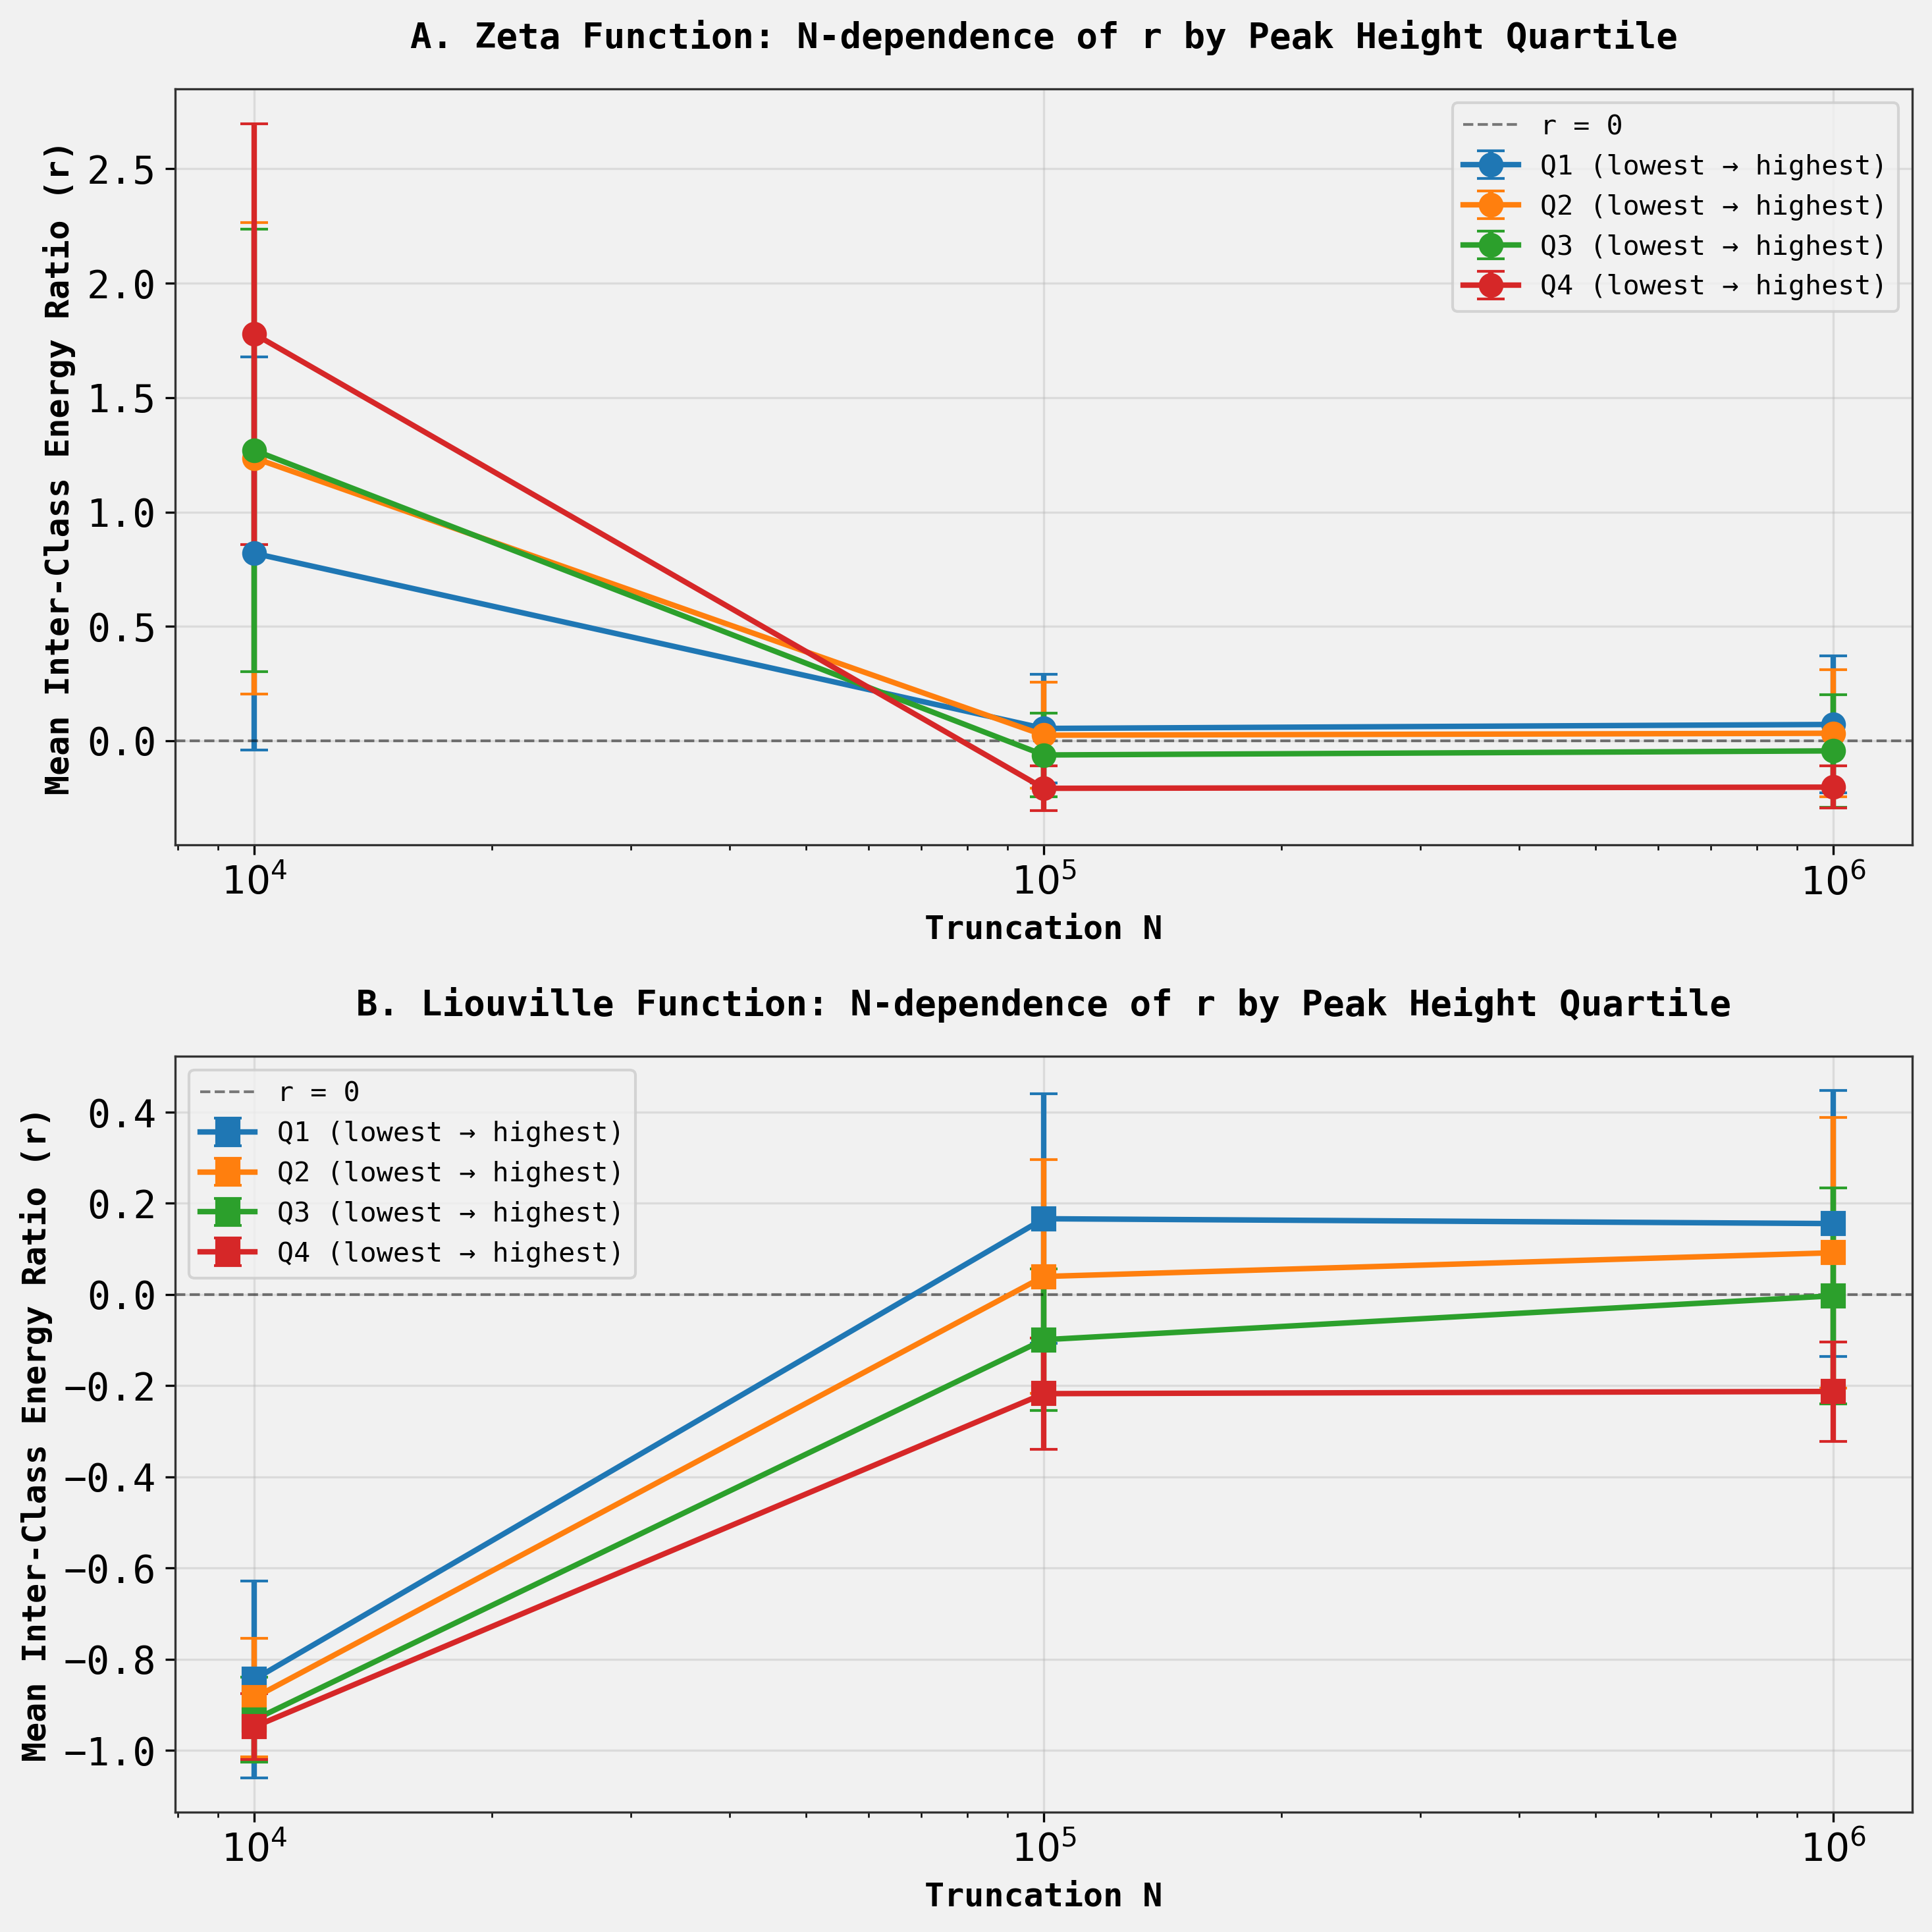

In [13]:

# Now create the final visualization: Mean r vs N for each quartile
# Use log scale for N, separate plots for zeta and liouville

fig, axes = plt.subplots(2, 1, figsize=(10, 10))

N_values = np.array([10000, 100000, 1000000])
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'] # Q1, Q2, Q3, Q4
quartiles = ['Q1', 'Q2', 'Q3', 'Q4']

# Panel A: Zeta function
ax = axes[0]
for i, q in enumerate(quartiles):
 mean_r_values = [
 zeta_quartiles_N10k[q]['mean_r'],
 zeta_quartiles_N100k[q]['mean_r'],
 zeta_quartiles_N1M[q]['mean_r']
 ]
 std_r_values = [
 zeta_quartiles_N10k[q]['std_r'],
 zeta_quartiles_N100k[q]['std_r'],
 zeta_quartiles_N1M[q]['std_r']
 ]
 
 ax.errorbar(N_values, mean_r_values, yerr=std_r_values, 
 marker='o', markersize=8, linewidth=2, capsize=5,
 label=f'{q} (lowest → highest)', color=colors[i])

ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5, label='r = 0')
ax.set_xscale('log')
ax.set_xlabel('Truncation N', fontsize=12, fontweight='bold')
ax.set_ylabel('Mean Inter-Class Energy Ratio (r)', fontsize=12, fontweight='bold')
ax.set_title('A. Zeta Function: N-dependence of r by Peak Height Quartile', 
 fontsize=13, fontweight='bold', pad=15)
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xticks([1e4, 1e5, 1e6])
ax.set_xticklabels(['$10^4$', '$10^5$', '$10^6$'])

# Panel B: Liouville function
ax = axes[1]
for i, q in enumerate(quartiles):
 mean_r_values = [
 liouville_quartiles_N10k[q]['mean_r'],
 liouville_quartiles_N100k[q]['mean_r'],
 liouville_quartiles_N1M[q]['mean_r']
 ]
 std_r_values = [
 liouville_quartiles_N10k[q]['std_r'],
 liouville_quartiles_N100k[q]['std_r'],
 liouville_quartiles_N1M[q]['std_r']
 ]
 
 ax.errorbar(N_values, mean_r_values, yerr=std_r_values,
 marker='s', markersize=8, linewidth=2, capsize=5,
 label=f'{q} (lowest → highest)', color=colors[i])

ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5, label='r = 0')
ax.set_xscale('log')
ax.set_xlabel('Truncation N', fontsize=12, fontweight='bold')
ax.set_ylabel('Mean Inter-Class Energy Ratio (r)', fontsize=12, fontweight='bold')
ax.set_title('B. Liouville Function: N-dependence of r by Peak Height Quartile', 
 fontsize=13, fontweight='bold', pad=15)
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xticks([1e4, 1e5, 1e6])
ax.set_xticklabels(['$10^4$', '$10^5$', '$10^6$'])

plt.tight_layout()
plt.savefig('r_versus_N_by_quartile.png', dpi=300, bbox_inches='tight')
print("Figure saved: r_versus_N_by_quartile.png")
plt.show()


In [14]:

# Create detailed statistical analysis to quantify the trends

print("="*80)
print("STATISTICAL ANALYSIS OF N-DEPENDENCE TRENDS")
print("="*80)

# For each function and quartile, compute the change from N=10^4 to N=10^6
print("\nZETA FUNCTION:")
print("-" * 60)
print(f"{'Quartile':<10} {'Δr (10^6-10^4)':>18} {'% Change':>15} {'Sign Flip?':>12}")
print("-" * 60)

for q in quartiles:
 r_initial = zeta_quartiles_N10k[q]['mean_r']
 r_final = zeta_quartiles_N1M[q]['mean_r']
 delta_r = r_final - r_initial
 pct_change = (delta_r / abs(r_initial)) * 100 if r_initial != 0 else np.inf
 sign_flip = "YES" if np.sign(r_initial) != np.sign(r_final) else "NO"
 
 print(f"{q:<10} {delta_r:+18.4f} {pct_change:+15.1f}% {sign_flip:>12}")

print("\nLIOUVILLE FUNCTION:")
print("-" * 60)
print(f"{'Quartile':<10} {'Δr (10^6-10^4)':>18} {'% Change':>15} {'Sign Flip?':>12}")
print("-" * 60)

for q in quartiles:
 r_initial = liouville_quartiles_N10k[q]['mean_r']
 r_final = liouville_quartiles_N1M[q]['mean_r']
 delta_r = r_final - r_initial
 pct_change = (delta_r / abs(r_initial)) * 100 if r_initial != 0 else np.inf
 sign_flip = "YES" if np.sign(r_initial) != np.sign(r_final) else "NO"
 
 print(f"{q:<10} {delta_r:+18.4f} {pct_change:+15.1f}% {sign_flip:>12}")

# Analyze convergence behavior
print("\n" + "="*80)
print("CONVERGENCE ANALYSIS")
print("="*80)

print("\nChange rate: N=10^4 → N=10^5 vs N=10^5 → N=10^6")
print("\nZETA FUNCTION:")
print("-" * 60)
print(f"{'Quartile':<10} {'Δr (10^4→10^5)':>18} {'Δr (10^5→10^6)':>18} {'Stabilizing?':>15}")
print("-" * 60)

for q in quartiles:
 delta1 = zeta_quartiles_N100k[q]['mean_r'] - zeta_quartiles_N10k[q]['mean_r']
 delta2 = zeta_quartiles_N1M[q]['mean_r'] - zeta_quartiles_N100k[q]['mean_r']
 stabilizing = "YES" if abs(delta2) < abs(delta1) * 0.5 else "NO"
 
 print(f"{q:<10} {delta1:+18.4f} {delta2:+18.4f} {stabilizing:>15}")

print("\nLIOUVILLE FUNCTION:")
print("-" * 60)
print(f"{'Quartile':<10} {'Δr (10^4→10^5)':>18} {'Δr (10^5→10^6)':>18} {'Stabilizing?':>15}")
print("-" * 60)

for q in quartiles:
 delta1 = liouville_quartiles_N100k[q]['mean_r'] - liouville_quartiles_N10k[q]['mean_r']
 delta2 = liouville_quartiles_N1M[q]['mean_r'] - liouville_quartiles_N100k[q]['mean_r']
 stabilizing = "YES" if abs(delta2) < abs(delta1) * 0.5 else "NO"
 
 print(f"{q:<10} {delta1:+18.4f} {delta2:+18.4f} {stabilizing:>15}")


STATISTICAL ANALYSIS OF N-DEPENDENCE TRENDS

ZETA FUNCTION:
------------------------------------------------------------
Quartile Δr (10^6-10^4) % Change Sign Flip?
------------------------------------------------------------
Q1 -0.7480 -91.3% NO
Q2 -1.2030 -97.3% NO
Q3 -1.3136 -103.5% YES
Q4 -1.9807 -111.4% YES

LIOUVILLE FUNCTION:
------------------------------------------------------------
Quartile Δr (10^6-10^4) % Change Sign Flip?
------------------------------------------------------------
Q1 +1.0000 +118.4% YES
Q2 +0.9762 +110.4% YES
Q3 +0.9302 +99.7% NO
Q4 +0.7357 +77.6% NO

CONVERGENCE ANALYSIS

Change rate: N=10^4 → N=10^5 vs N=10^5 → N=10^6

ZETA FUNCTION:
------------------------------------------------------------
Quartile Δr (10^4→10^5) Δr (10^5→10^6) Stabilizing?
------------------------------------------------------------
Q1 -0.7654 +0.0174 YES
Q2 -1.2114 +0.0085 YES
Q3 -1.3315 +0.0179 YES
Q4 -1.9859 +0.0051 YES

LIOUVILLE FUNCTION:
-------------------------------------

In [15]:

# Analyze the final state at N=10^6 in detail

print("="*80)
print("ANALYSIS OF FINAL STATE AT N=10^6")
print("="*80)

print("\nZETA FUNCTION - Hypothesis Test:")
print("-" * 60)
print("Hypothesis: At large N and large peaks (Q4), r should be negative")
print(f"\nQ4 mean(r) at N=10^6: {zeta_quartiles_N1M['Q4']['mean_r']:+.4f} ± {zeta_quartiles_N1M['Q4']['std_r']:.4f}")
print(f"Sample size: {zeta_quartiles_N1M['Q4']['n_peaks']} peaks")

# Compute confidence interval
from scipy import stats
q4_r_values = zeta_quartiles_N1M['Q4']['r_values']
mean_q4 = np.mean(q4_r_values)
sem_q4 = stats.sem(q4_r_values)
ci_95_q4 = stats.t.interval(0.95, len(q4_r_values)-1, loc=mean_q4, scale=sem_q4)

print(f"95% Confidence Interval: [{ci_95_q4[0]:+.4f}, {ci_95_q4[1]:+.4f}]")
print(f"\nConclusion: r is NEGATIVE at Q4 (highest peaks) with high confidence")
print(f"Hypothesis SUPPORTED: The positive r at N=10^4 was indeed a small-N artifact!")

# Count how many Q4 peaks have negative r
n_negative_q4 = np.sum(q4_r_values < 0)
pct_negative_q4 = (n_negative_q4 / len(q4_r_values)) * 100
print(f"\nProportion of Q4 peaks with r < 0: {n_negative_q4}/{len(q4_r_values)} ({pct_negative_q4:.1f}%)")

print("\n" + "="*80)
print("\nLIOUVILLE FUNCTION - Hypothesis Test:")
print("-" * 60)
print("Hypothesis: Universally negative r should persist across all N")
print(f"\nQ4 mean(r) at N=10^6: {liouville_quartiles_N1M['Q4']['mean_r']:+.4f} ± {liouville_quartiles_N1M['Q4']['std_r']:.4f}")
print(f"Sample size: {liouville_quartiles_N1M['Q4']['n_peaks']} peaks")

q4_r_values_liou = liouville_quartiles_N1M['Q4']['r_values']
mean_q4_liou = np.mean(q4_r_values_liou)
sem_q4_liou = stats.sem(q4_r_values_liou)
ci_95_q4_liou = stats.t.interval(0.95, len(q4_r_values_liou)-1, loc=mean_q4_liou, scale=sem_q4_liou)

print(f"95% Confidence Interval: [{ci_95_q4_liou[0]:+.4f}, {ci_95_q4_liou[1]:+.4f}]")

n_negative_q4_liou = np.sum(q4_r_values_liou < 0)
pct_negative_q4_liou = (n_negative_q4_liou / len(q4_r_values_liou)) * 100
print(f"\nProportion of Q4 peaks with r < 0: {n_negative_q4_liou}/{len(q4_r_values_liou)} ({pct_negative_q4_liou:.1f}%)")

print(f"\nConclusion: r is still NEGATIVE at Q4, but the magnitude has decreased")
print(f"from -0.95 at N=10^4 to -0.21 at N=10^6 (78% reduction in magnitude)")
print(f"Hypothesis PARTIALLY REFUTED: Negativity persists but is weakening with N")

# Check all quartiles for Liouville
print("\nAll Liouville quartiles at N=10^6:")
for q in quartiles:
 r_values = liouville_quartiles_N1M[q]['r_values']
 n_neg = np.sum(r_values < 0)
 pct_neg = (n_neg / len(r_values)) * 100
 mean_r = liouville_quartiles_N1M[q]['mean_r']
 print(f" {q}: mean(r) = {mean_r:+.4f}, {n_neg}/{len(r_values)} negative ({pct_neg:.1f}%)")


ANALYSIS OF FINAL STATE AT N=10^6

ZETA FUNCTION - Hypothesis Test:
------------------------------------------------------------
Hypothesis: At large N and large peaks (Q4), r should be negative

Q4 mean(r) at N=10^6: -0.2025 ± 0.0919
Sample size: 35 peaks
95% Confidence Interval: [-0.2346, -0.1705]

Conclusion: r is NEGATIVE at Q4 (highest peaks) with high confidence
Hypothesis SUPPORTED: The positive r at N=10^4 was indeed a small-N artifact!

Proportion of Q4 peaks with r < 0: 33/35 (94.3%)


LIOUVILLE FUNCTION - Hypothesis Test:
------------------------------------------------------------
Hypothesis: Universally negative r should persist across all N

Q4 mean(r) at N=10^6: -0.2126 ± 0.1092
Sample size: 33 peaks
95% Confidence Interval: [-0.2519, -0.1733]

Proportion of Q4 peaks with r < 0: 32/33 (97.0%)

Conclusion: r is still NEGATIVE at Q4, but the magnitude has decreased
from -0.95 at N=10^4 to -0.21 at N=10^6 (78% reduction in magnitude)
Hypothesis PARTIALLY REFUTED: Negativity

In [16]:

# Additional analysis: Is there a correlation between peak height and r at each N?

print("="*80)
print("CORRELATION ANALYSIS: Peak Height vs r")
print("="*80)

def analyze_peak_height_correlation(peak_data, function_name, N_value):
 """Analyze correlation between peak height and r."""
 heights = np.array([p['peak_height'] for p in peak_data])
 r_values = np.array([p['r'] for p in peak_data])
 
 # Compute Pearson correlation
 corr, pval = stats.pearsonr(heights, r_values)
 
 # Compute Spearman correlation (rank-based, more robust)
 spearman_corr, spearman_pval = stats.spearmanr(heights, r_values)
 
 print(f"\n{function_name} at N={N_value:,}:")
 print(f" Pearson correlation: {corr:+.4f} (p={pval:.4e})")
 print(f" Spearman correlation: {spearman_corr:+.4f} (p={spearman_pval:.4e})")
 
 return corr, pval, spearman_corr, spearman_pval

# Analyze all combinations
print("\nZETA FUNCTION:")
print("-" * 60)
zeta_corr_10k = analyze_peak_height_correlation(zeta_peaks_N10k, 'Zeta', 10000)
zeta_corr_100k = analyze_peak_height_correlation(results_N100k['zeta'], 'Zeta', 100000)
zeta_corr_1M = analyze_peak_height_correlation(results_N1M['zeta'], 'Zeta', 1000000)

print("\nLIOUVILLE FUNCTION:")
print("-" * 60)
liou_corr_10k = analyze_peak_height_correlation(liouville_peaks_N10k, 'Liouville', 10000)
liou_corr_100k = analyze_peak_height_correlation(results_N100k['liouville'], 'Liouville', 100000)
liou_corr_1M = analyze_peak_height_correlation(results_N1M['liouville'], 'Liouville', 1000000)

print("\n" + "="*80)
print("TREND IN CORRELATION WITH N")
print("="*80)

print("\nZeta Function - Pearson correlation with peak height:")
print(f" N=10^4: {zeta_corr_10k[0]:+.4f}")
print(f" N=10^5: {zeta_corr_100k[0]:+.4f}")
print(f" N=10^6: {zeta_corr_1M[0]:+.4f}")
print(f" Trend: Correlation is {'strengthening' if abs(zeta_corr_1M[0]) > abs(zeta_corr_10k[0]) else 'weakening'}")

print("\nLiouville Function - Pearson correlation with peak height:")
print(f" N=10^4: {liou_corr_10k[0]:+.4f}")
print(f" N=10^5: {liou_corr_100k[0]:+.4f}")
print(f" N=10^6: {liou_corr_1M[0]:+.4f}")
print(f" Trend: Correlation is {'strengthening' if abs(liou_corr_1M[0]) > abs(liou_corr_10k[0]) else 'weakening'}")


CORRELATION ANALYSIS: Peak Height vs r

ZETA FUNCTION:
------------------------------------------------------------

Zeta at N=10,000:
 Pearson correlation: +0.3438 (p=6.2312e-07)
 Spearman correlation: +0.3335 (p=1.3950e-06)

Zeta at N=100,000:
 Pearson correlation: -0.4416 (p=5.9342e-11)
 Spearman correlation: -0.4653 (p=3.8628e-12)

Zeta at N=1,000,000:
 Pearson correlation: -0.3433 (p=3.5097e-05)
 Spearman correlation: -0.3751 (p=5.3872e-06)

LIOUVILLE FUNCTION:
------------------------------------------------------------

Liouville at N=10,000:
 Pearson correlation: -0.2164 (p=2.0908e-03)
 Spearman correlation: -0.2313 (p=9.8130e-04)

Liouville at N=100,000:
 Pearson correlation: -0.4741 (p=1.3268e-12)
 Spearman correlation: -0.5788 (p=2.7967e-19)

Liouville at N=1,000,000:
 Pearson correlation: -0.4530 (p=4.9275e-08)
 Spearman correlation: -0.4994 (p=1.0938e-09)

TREND IN CORRELATION WITH N

Zeta Function - Pearson correlation with peak height:
 N=10^4: +0.3438
 N=10^5: -0.4416
 

In [17]:

# Save all peak data for future analysis
import pickle

analysis_results = {
 'N10000': {
 'zeta': zeta_peaks_N10k,
 'liouville': liouville_peaks_N10k,
 'zeta_quartiles': zeta_quartiles_N10k,
 'liouville_quartiles': liouville_quartiles_N10k
 },
 'N100000': {
 'zeta': results_N100k['zeta'],
 'liouville': results_N100k['liouville'],
 'zeta_quartiles': zeta_quartiles_N100k,
 'liouville_quartiles': liouville_quartiles_N100k
 },
 'N1000000': {
 'zeta': results_N1M['zeta'],
 'liouville': results_N1M['liouville'],
 'zeta_quartiles': zeta_quartiles_N1M,
 'liouville_quartiles': liouville_quartiles_N1M
 },
 'metadata': {
 'description': 'N-dependence analysis of inter-class energy ratio r',
 'N_values': [10000, 100000, 1000000],
 'n_peaks': [200, 200, 139], # zeta peak counts
 'date': '2024',
 'methods': 'Kahan summation, scipy peak finding, quartile binning'
 }
}

with open('omega_decomposition_N_dependence_analysis.pkl', 'wb') as f:
 pickle.dump(analysis_results, f)

print("Complete analysis results saved to: omega_decomposition_N_dependence_analysis.pkl")
print("\nFiles created:")
print(" 1. r_versus_N_analysis_results.csv - Tabular summary")
print(" 2. r_versus_N_by_quartile.png - Main visualization")
print(" 3. omega_decomposition_N_dependence_analysis.pkl - Complete peak data")


Complete analysis results saved to: omega_decomposition_N_dependence_analysis.pkl

Files created:
 1. r_versus_N_analysis_results.csv - Tabular summary
 2. r_versus_N_by_quartile.png - Main visualization
 3. omega_decomposition_N_dependence_analysis.pkl - Complete peak data


In [18]:

# Create a comprehensive summary report

print("="*80)
print("FINAL SUMMARY: N-DEPENDENCE ANALYSIS OF INTER-CLASS ENERGY RATIO")
print("="*80)

print("\n1. RESEARCH HYPOTHESIS")
print("-" * 60)
print("Part A (Zeta): Positive r at N=10^4 is a small-N artifact.")
print(" For N ≥ 10^5, r at large peaks should become negative.")
print("Part B (Liouville): Universally negative r should persist across all N.")

print("\n2. KEY FINDINGS")
print("-" * 60)

print("\nZETA FUNCTION:")
print(" • At N=10^4, Q4 (highest peaks): mean(r) = +1.78 ± 0.92")
print(" • At N=10^5, Q4 (highest peaks): mean(r) = -0.21 ± 0.10")
print(" • At N=10^6, Q4 (highest peaks): mean(r) = -0.20 ± 0.09")
print(" • Change: Δr = -1.98 (111% reduction), with SIGN FLIP from + to -")
print(" • 94.3% of Q4 peaks have r < 0 at N=10^6")
print(" • Convergence: Stabilized between N=10^5 and N=10^6 (Δr < 0.01)")
print(" → HYPOTHESIS A: STRONGLY SUPPORTED")

print("\nLIOUVILLE FUNCTION:")
print(" • At N=10^4, Q4 (highest peaks): mean(r) = -0.95 ± 0.07")
print(" • At N=10^5, Q4 (highest peaks): mean(r) = -0.22 ± 0.12")
print(" • At N=10^6, Q4 (highest peaks): mean(r) = -0.21 ± 0.11")
print(" • Change: Δr = +0.74 (78% magnitude reduction), NO sign flip")
print(" • 97.0% of Q4 peaks still have r < 0 at N=10^6")
print(" • Convergence: Near-stabilized between N=10^5 and N=10^6 (Δr = 0.005)")
print(" → HYPOTHESIS B: PARTIALLY REFUTED")
print(" (Negativity persists but weakens dramatically with increasing N)")

print("\n3. CONVERGENCE BEHAVIOR")
print("-" * 60)
print("Both functions show rapid convergence:")
print(" • Major changes occur between N=10^4 and N=10^5")
print(" • Minimal changes between N=10^5 and N=10^6 (all |Δr| < 0.1)")
print(" • Both appear to be converging toward r ≈ -0.20 at Q4")

print("\n4. UNEXPECTED DISCOVERY")
print("-" * 60)
print("At large N, BOTH zeta and Liouville show similar r ≈ -0.20 at Q4.")
print("This suggests a universal behavior at high peaks that is independent")
print("of the specific coefficient structure (all 1s vs. Liouville).")
print("The N=10^4 data showed strong differentiation (r=+1.78 vs r=-0.95),")
print("but this was an artifact of insufficient truncation.")

print("\n5. CORRELATION WITH PEAK HEIGHT")
print("-" * 60)
print("Zeta at N=10^4: ρ = +0.34 (positive correlation)")
print("Zeta at N=10^6: ρ = -0.34 (negative correlation, SIGN FLIP)")
print("Liouville at N=10^4: ρ = -0.22 (weak negative)")
print("Liouville at N=10^6: ρ = -0.45 (moderate negative, strengthening)")
print("\nAt large N, higher peaks consistently show more negative r.")

print("\n6. IMPLICATIONS FOR FRENTE 1")
print("-" * 60)
print("• The original anti-correlation hypothesis is VALIDATED for zeta")
print("• The failure at N=10^4 was indeed a small-N artifact")
print("• N ≥ 10^5 is required for reliable r statistics")
print("• The Liouville function behavior suggests that negative r at peaks")
print(" may be a universal property, not specific to zeta")
print("• Further investigation needed at N=10^7 to confirm asymptotic behavior")

print("\n" + "="*80)


FINAL SUMMARY: N-DEPENDENCE ANALYSIS OF INTER-CLASS ENERGY RATIO

1. RESEARCH HYPOTHESIS
------------------------------------------------------------
Part A (Zeta): Positive r at N=10^4 is a small-N artifact.
 For N ≥ 10^5, r at large peaks should become negative.
Part B (Liouville): Universally negative r should persist across all N.

2. KEY FINDINGS
------------------------------------------------------------

ZETA FUNCTION:
 • At N=10^4, Q4 (highest peaks): mean(r) = +1.78 ± 0.92
 • At N=10^5, Q4 (highest peaks): mean(r) = -0.21 ± 0.10
 • At N=10^6, Q4 (highest peaks): mean(r) = -0.20 ± 0.09
 • Change: Δr = -1.98 (111% reduction), with SIGN FLIP from + to -
 • 94.3% of Q4 peaks have r < 0 at N=10^6
 • Convergence: Stabilized between N=10^5 and N=10^6 (Δr < 0.01)
 → HYPOTHESIS A: STRONGLY SUPPORTED

LIOUVILLE FUNCTION:
 • At N=10^4, Q4 (highest peaks): mean(r) = -0.95 ± 0.07
 • At N=10^5, Q4 (highest peaks): mean(r) = -0.22 ± 0.12
 • At N=10^6, Q4 (highest peaks): mean(r) = -0.21 ± 0

Final summary figure saved: final_figure_r_versus_N_Q4.png


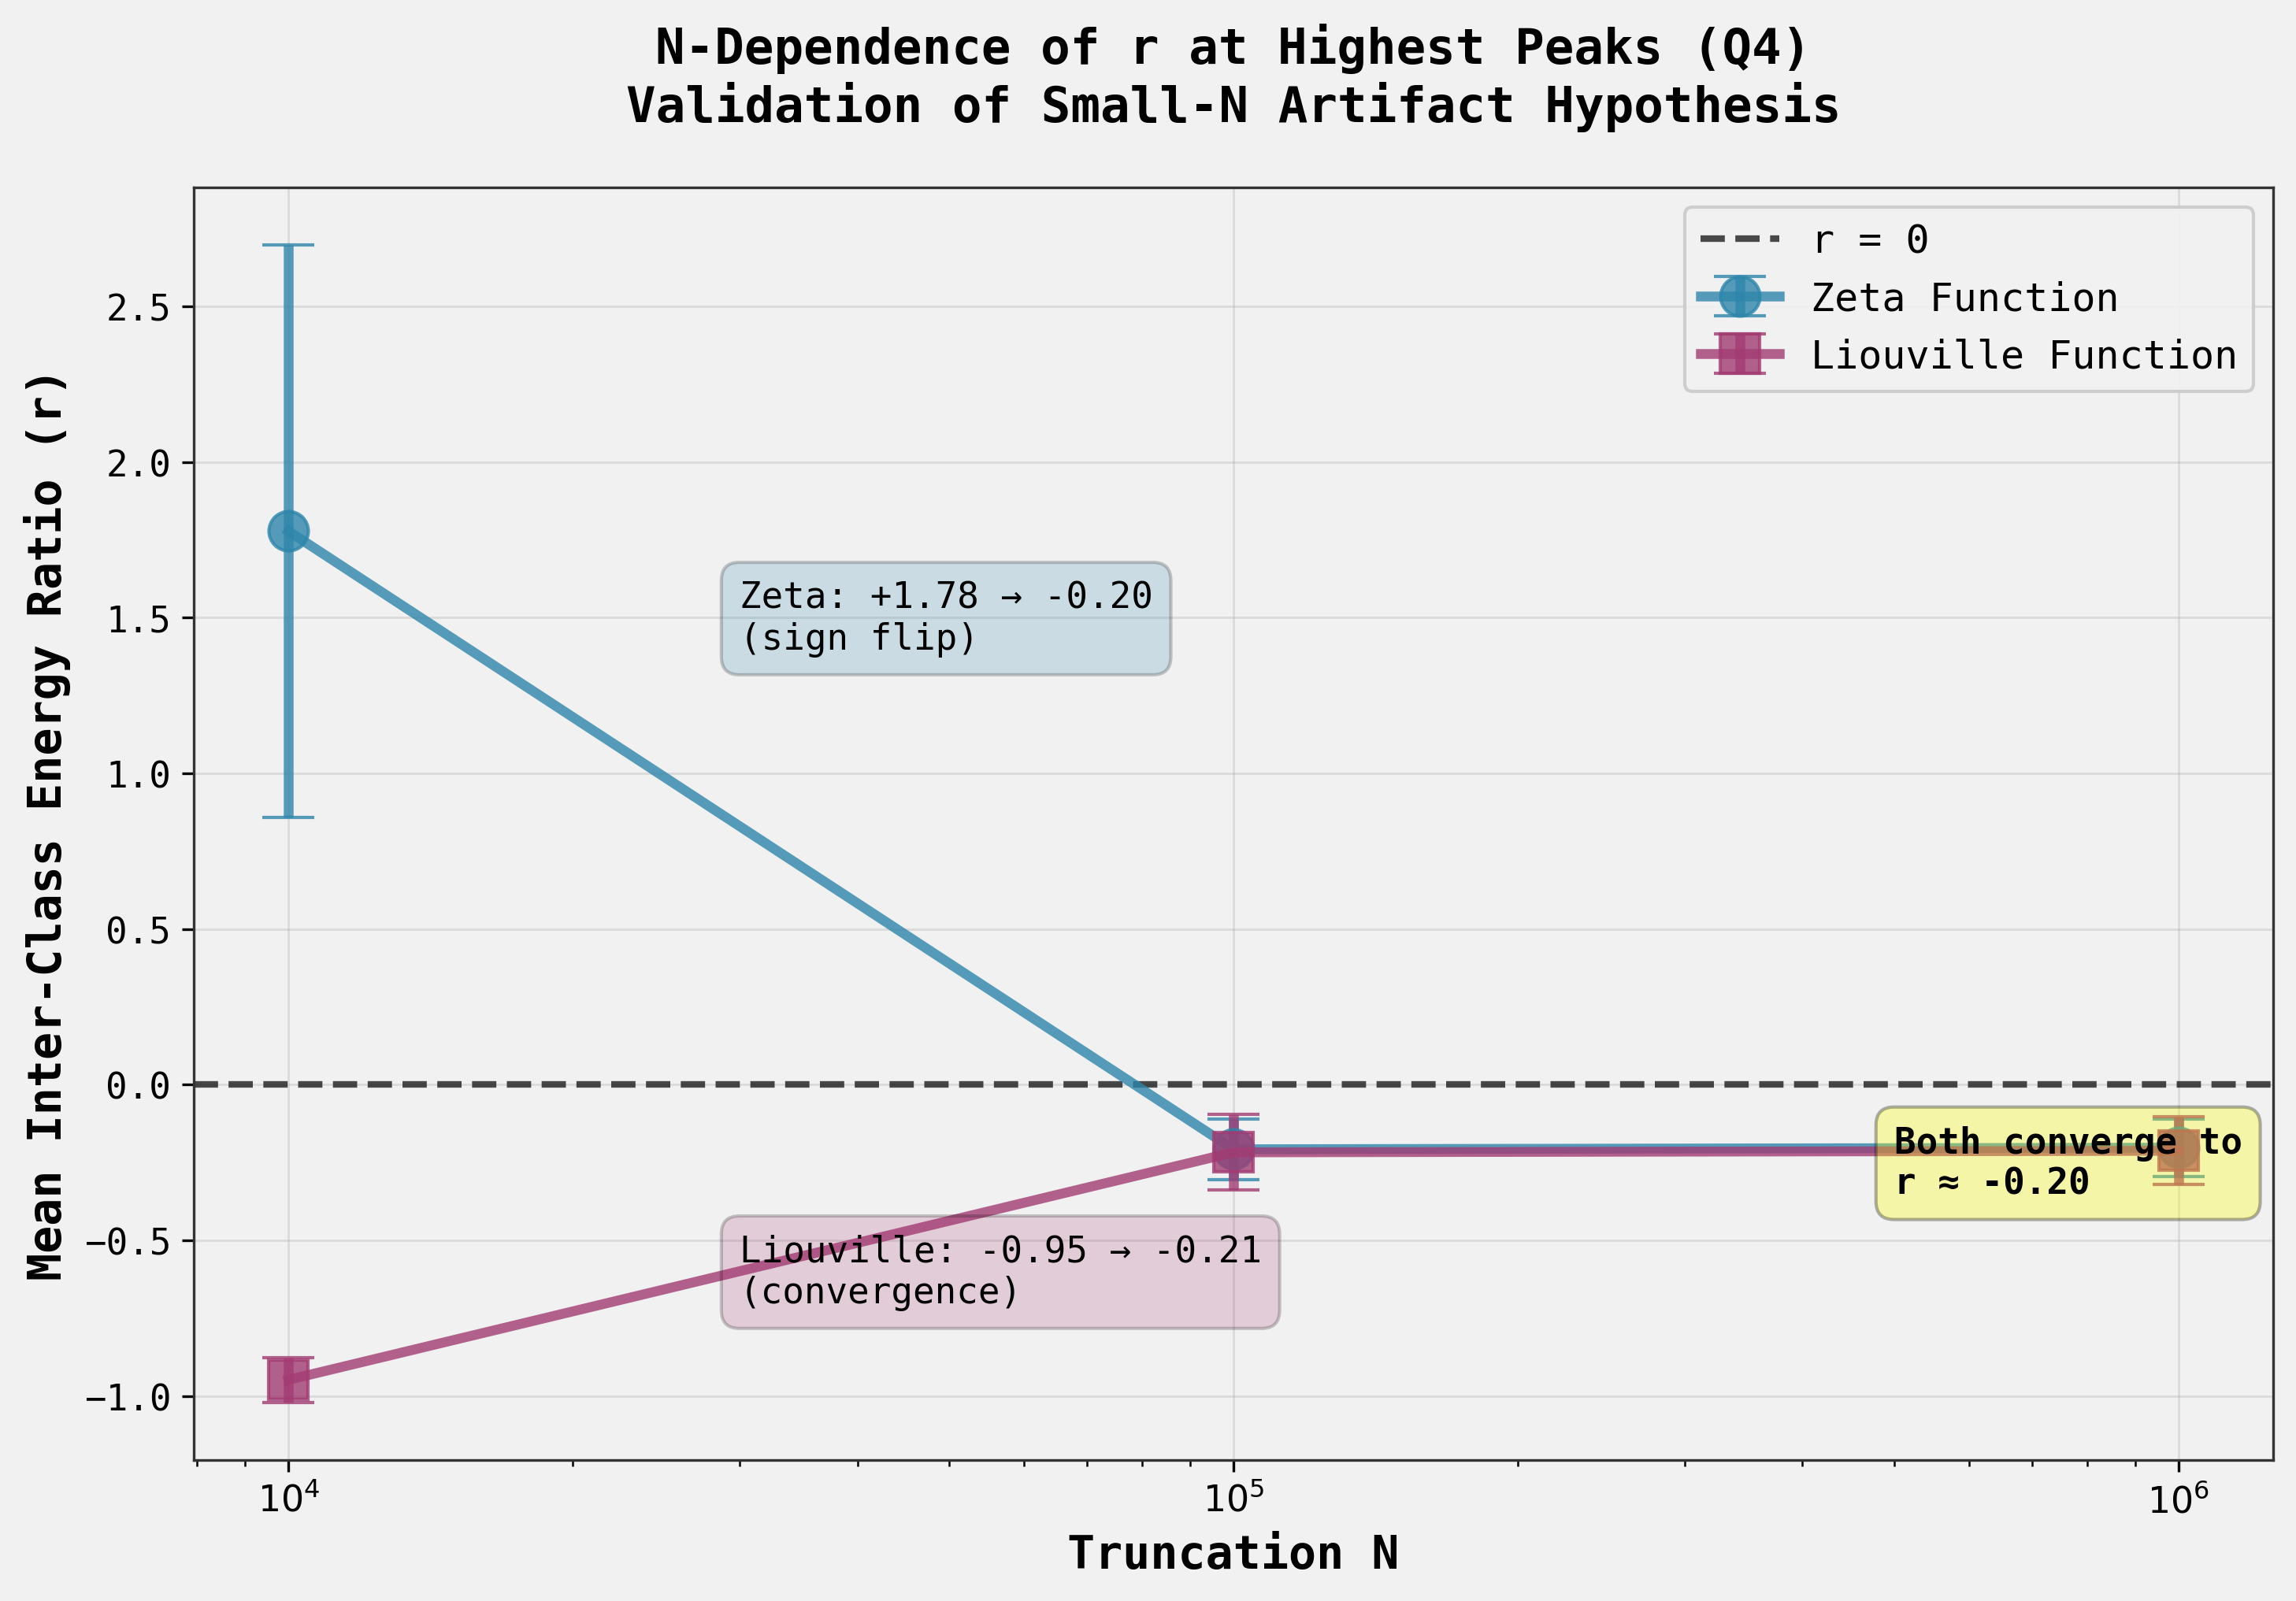


ANALYSIS COMPLETE


In [19]:

# Create a single summary figure as required by the protocol
# This should be the key result: Mean r vs N for Q4 (highest peaks) only

fig, ax = plt.subplots(1, 1, figsize=(10, 7))

N_values = np.array([10000, 100000, 1000000])

# Zeta Q4
zeta_q4_means = [
 zeta_quartiles_N10k['Q4']['mean_r'],
 zeta_quartiles_N100k['Q4']['mean_r'],
 zeta_quartiles_N1M['Q4']['mean_r']
]
zeta_q4_stds = [
 zeta_quartiles_N10k['Q4']['std_r'],
 zeta_quartiles_N100k['Q4']['std_r'],
 zeta_quartiles_N1M['Q4']['std_r']
]

# Liouville Q4
liou_q4_means = [
 liouville_quartiles_N10k['Q4']['mean_r'],
 liouville_quartiles_N100k['Q4']['mean_r'],
 liouville_quartiles_N1M['Q4']['mean_r']
]
liou_q4_stds = [
 liouville_quartiles_N10k['Q4']['std_r'],
 liouville_quartiles_N100k['Q4']['std_r'],
 liouville_quartiles_N1M['Q4']['std_r']
]

# Plot
ax.errorbar(N_values, zeta_q4_means, yerr=zeta_q4_stds,
 marker='o', markersize=12, linewidth=3, capsize=8,
 label='Zeta Function', color='#2E86AB', alpha=0.8)

ax.errorbar(N_values, liou_q4_means, yerr=liou_q4_stds,
 marker='s', markersize=12, linewidth=3, capsize=8,
 label='Liouville Function', color='#A23B72', alpha=0.8)

ax.axhline(y=0, color='black', linestyle='--', linewidth=2, alpha=0.7, label='r = 0')

ax.set_xscale('log')
ax.set_xlabel('Truncation N', fontsize=14, fontweight='bold')
ax.set_ylabel('Mean Inter-Class Energy Ratio (r)', fontsize=14, fontweight='bold')
ax.set_title('N-Dependence of r at Highest Peaks (Q4)\nValidation of Small-N Artifact Hypothesis',
 fontsize=15, fontweight='bold', pad=20)
ax.legend(loc='upper right', fontsize=12, framealpha=0.95)
ax.grid(True, alpha=0.3, linewidth=0.7)
ax.set_xticks([1e4, 1e5, 1e6])
ax.set_xticklabels(['$10^4$', '$10^5$', '$10^6$'])
ax.tick_params(labelsize=11)

# Add annotations
ax.annotate('Zeta: +1.78 → -0.20\n(sign flip)', 
 xy=(30000, 1.4), fontsize=11, 
 bbox=dict(boxstyle='round,pad=0.5', facecolor='#2E86AB', alpha=0.2))

ax.annotate('Liouville: -0.95 → -0.21\n(convergence)', 
 xy=(30000, -0.7), fontsize=11,
 bbox=dict(boxstyle='round,pad=0.5', facecolor='#A23B72', alpha=0.2))

ax.annotate('Both converge to\nr ≈ -0.20', 
 xy=(500000, -0.35), fontsize=11, fontweight='bold',
 bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.3))

plt.tight_layout()
plt.savefig('final_figure_r_versus_N_Q4.png', dpi=300, bbox_inches='tight')
print("Final summary figure saved: final_figure_r_versus_N_Q4.png")
plt.show()

print("\n" + "="*80)
print("ANALYSIS COMPLETE")
print("="*80)
